In [99]:
from datascience import * 
import numpy as np
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
import matplotlib.pyplot as plt 

In [ ]:
exoplanet_csv = "koi_dataset.csv"
exoplanets = Table().read_table(exoplanet_csv)
exoplanets

In [221]:
cleaned_exoplanets = exoplanets.where("koi_vet_stat", are.equal_to("Done")).where("koi_disposition", are.not_equal_to("CANDIDATE")).where("koi_model_snr", are.not_equal_to(np.nan))

ninety_percentile = np.nanpercentile(cleaned_exoplanets.column("koi_model_snr"), 80)
confirmed = cleaned_exoplanets.where("koi_model_snr", are.below_or_equal_to(ninety_percentile)).where("koi_disposition", are.equal_to("CONFIRMED"))
false_positives = cleaned_exoplanets.where("koi_model_snr", are.below_or_equal_to(ninety_percentile)).where("koi_disposition", are.equal_to("FALSE POSITIVE"))

## TRANSIT PROPERTIES

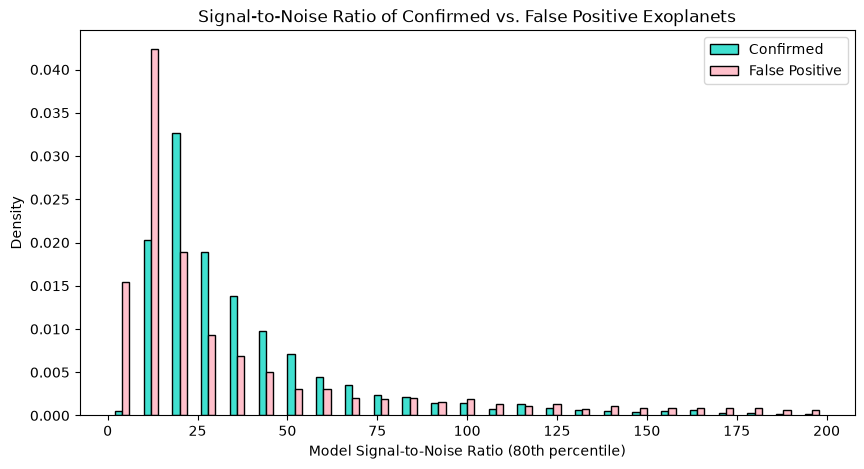

In [227]:
snr_confirmed = confirmed.column("koi_model_snr")
snr_fp = false_positives.column("koi_model_snr")

plt.figure(figsize=(10,5))

plt.hist(
    [snr_confirmed, snr_fp], 
    bins=25,
    histtype="bar",
    align="mid",
    density=True, 
    label=["Confirmed", "False Positive"], 
    color=["turquoise", "pink"],
    rwidth=0.5
)

plt.xlabel("Model Signal-to-Noise Ratio (80th percentile)")
plt.ylabel("Density")
plt.title("Signal-to-Noise Ratio of Confirmed vs. False Positive Exoplanets")
plt.legend()

In [223]:
# add stats like mean, median, percentiles

## PLANETARY PROPERTIES

## STELLAR PROPERTIES